## Analysis of the processed dataset

In [2]:
import sys
project_root = '/home/onyxia/work/election_modeling_uhcp'
sys.path.insert(0, project_root)
from src.components.data_processing.data_loader import DataLoader

In [3]:
import os
import s3fs
os.environ["AWS_ACCESS_KEY_ID"] = '93LJKWNTELDM5ZCZAZET'
os.environ["AWS_SECRET_ACCESS_KEY"] = 'ArefC2F4j9+oM9UvlFLVxbG1507AJPv0jbfqWVe7'
os.environ["AWS_SESSION_TOKEN"] = 'eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiI5M0xKS1dOVEVMRE01WkNaQVpFVCIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzY4MjE3ODI4LCJhenAiOiJvbnl4aWEiLCJlbWFpbCI6ImFydGh1ci5tYW5jZWF1QHN0dWRlbnQtY3MuZnIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZXhwIjoxNzY5MzMyODkxLCJmYW1pbHlfbmFtZSI6Ik1hbmNlYXUiLCJnaXZlbl9uYW1lIjoiQXJ0aHVyIiwiZ3JvdXBzIjpbIlVTRVJfT05ZWElBIl0sImlhdCI6MTc2ODcyODA5MCwiaXNzIjoiaHR0cHM6Ly9hdXRoLmxhYi5zc3BjbG91ZC5mci9hdXRoL3JlYWxtcy9zc3BjbG91ZCIsImp0aSI6Im9ucnRydDplZTVlZjY4My1iMGNjLTM1Y2EtMWQ0MC1jOWE5MTZiNjU3ZDAiLCJsb2NhbGUiOiJlbiIsIm5hbWUiOiJBcnRodXIgTWFuY2VhdSIsInBvbGljeSI6InN0c29ubHkiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJhcnRodXJtYW5jZWF1IiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiI3ODBlNThkMS1mMTFmLTQzZjYtN2UwMS00NzJhM2UwNTBkNTYiLCJzdWIiOiJiYzc3Yjk3YS1lN2VkLTQ4ZWMtYmQ4Zi1lNzBjYjZhMTYyZGIiLCJ0eXAiOiJCZWFyZXIifQ.YZ2qM_HbmC2MoTf540UsZt1xvI9FiFm3y751oaa_TDbEeCIrWyUwsEsJ-IgvZDEEbQAeUcAqMdZWQ1VjTCuIXg'
os.environ["AWS_DEFAULT_REGION"] = 'us-east-1'
fs = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])

In [4]:
dataset = DataLoader().load_dataset("s3://arthurmanceau/election_modeling_uhcp/data/derived/processed/data_ppar_pvoteG_pvoteC_pvoteD_pvoteCG_pvoteCD_1970_presidentiel_legislative_20251216_165954.parquet", fs=fs)

2026-01-18 16:19:17.423 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:57 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/derived/processed/data_ppar_pvoteG_pvoteC_pvoteD_pvoteCG_pvoteCD_1970_presidentiel_legislative_20251216_165954.parquet...
2026-01-18 16:19:50.537 | DEBUG    | src.components.data_processing.data_loader:load_dataset:189 - Dataset loaded: (788902, 1104)


In [42]:
N = dataset.isnull().mean(axis=0)

In [43]:
N

codecommune                    0.000000
inscrits                       0.000000
pvoteppar                      0.000000
pvotepvoteG                    0.000000
pvotepvoteC                    0.000000
                                 ...   
menagescommunes/nmen_          0.957786
menagescommunes/permencomp_    0.957786
menagescommunes/pmencomp_      0.957786
menagescommunes/nmencomp_      0.957786
menagescommunes/plm_           0.957786
Length: 1104, dtype: float64

In [38]:
import matplotlib.pyplot as plt

<Axes: >

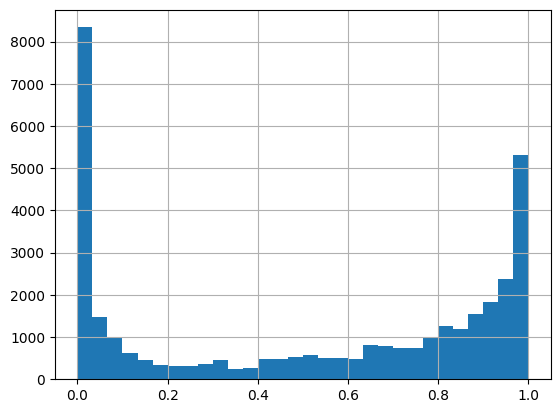

In [40]:
dataset[dataset['annee']==2017]['cspcommunes/perindp'].hist(bins=30)

In [6]:
dataset.columns.to_list()

['codecommune',
 'inscrits',
 'pvoteppar',
 'pvotepvoteG',
 'pvotepvoteC',
 'pvotepvoteD',
 'pvotepvoteCG',
 'pvotepvoteCD',
 'pvotepreviousppar',
 'pvotepreviouspreviousppar',
 'pvotepreviouspvoteG',
 'pvotepreviouspreviouspvoteG',
 'pvotepreviouspvoteC',
 'pvotepreviouspreviouspvoteC',
 'pvotepreviouspvoteD',
 'pvotepreviouspreviouspvoteD',
 'pvotepreviouspvoteCG',
 'pvotepreviouspreviouspvoteCG',
 'pvotepreviouspvoteCD',
 'pvotepreviouspreviouspvoteCD',
 'dep',
 'agesexcommunes/popf014',
 'agesexcommunes/popf1539',
 'agesexcommunes/popf4059',
 'agesexcommunes/popf60p',
 'agesexcommunes/poph014',
 'agesexcommunes/poph1539',
 'agesexcommunes/poph4059',
 'agesexcommunes/poph60p',
 'agesexcommunes/agef',
 'agesexcommunes/ageh',
 'agesexcommunes/popf',
 'agesexcommunes/poph',
 'agesexcommunes/propf',
 'agesexcommunes/age',
 'agesexcommunes/pop',
 'agesexcommunes/propf014',
 'agesexcommunes/propf1539',
 'agesexcommunes/propf4059',
 'agesexcommunes/propf60p',
 'agesexcommunes/prop014',
 'a

In [33]:
dataset[['annee', 'cspcommunes/perindp']].dropna()['annee'].unique()

array([2017, 1988, 2022, 1995, 2027, 1965, 1969, 2002, 1974, 2007, 2012,
       1981])

In [32]:
N[N<0.2].to_frame().T.columns.to_list()

['codecommune',
 'inscrits',
 'pvoteppar',
 'pvotepvoteG',
 'pvotepvoteC',
 'pvotepvoteD',
 'pvotepvoteCG',
 'pvotepvoteCD',
 'pvotepreviousppar',
 'pvotepreviouspreviousppar',
 'pvotepreviouspvoteG',
 'pvotepreviouspreviouspvoteG',
 'pvotepreviouspvoteC',
 'pvotepreviouspreviouspvoteC',
 'pvotepreviouspvoteD',
 'pvotepreviouspreviouspvoteD',
 'pvotepreviouspvoteCG',
 'pvotepreviouspreviouspvoteCG',
 'pvotepreviouspvoteCD',
 'pvotepreviouspreviouspvoteCD',
 'dep',
 'agesexcommunes/popf014',
 'agesexcommunes/popf1539',
 'agesexcommunes/popf4059',
 'agesexcommunes/popf60p',
 'agesexcommunes/poph014',
 'agesexcommunes/poph1539',
 'agesexcommunes/poph4059',
 'agesexcommunes/poph60p',
 'agesexcommunes/agef',
 'agesexcommunes/ageh',
 'agesexcommunes/popf',
 'agesexcommunes/poph',
 'agesexcommunes/propf',
 'agesexcommunes/age',
 'agesexcommunes/pop',
 'agesexcommunes/propf014',
 'agesexcommunes/propf1539',
 'agesexcommunes/propf4059',
 'agesexcommunes/propf60p',
 'agesexcommunes/prop014',
 'a

In [6]:
import numpy as np
import pandas as pd
data = np.load('../../data/raw/geo_data/distance_cities/distance_matrix.npz')

In [7]:
m = pd.read_parquet('../../data/raw/geo_data/distance_cities/mapping.parquet')

In [ ]:
m[m.iloc[:,0]=="05039"].index[0]

np.int64(1)

{'03252': 0,
 '05039': 1,
 '16203': 2,
 '16372': 3,
 '24002': 4,
 '24011': 5,
 '24026': 6,
 '24098': 7,
 '24102': 8,
 '24108': 9,
 '24115': 10,
 '24135': 11,
 '24138': 12,
 '24139': 13,
 '24175': 14,
 '24208': 15,
 '24256': 16,
 '24263': 17,
 '24312': 18,
 '24313': 19,
 '24326': 20,
 '24330': 21,
 '24337': 22,
 '24426': 23,
 '24431': 24,
 '24443': 25,
 '24540': 26,
 '24557': 27,
 '27447': 28,
 '31166': 29,
 '36006': 30,
 '36012': 31,
 '36014': 32,
 '36032': 33,
 '36033': 34,
 '36042': 35,
 '36048': 36,
 '36062': 37,
 '36069': 38,
 '36072': 39,
 '36077': 40,
 '36080': 41,
 '36081': 42,
 '36082': 43,
 '36086': 44,
 '36090': 45,
 '36092': 46,
 '36103': 47,
 '36107': 48,
 '36117': 49,
 '36131': 50,
 '36154': 51,
 '36155': 52,
 '36158': 53,
 '36160': 54,
 '36161': 55,
 '36166': 56,
 '36192': 57,
 '36200': 58,
 '36216': 59,
 '36219': 60,
 '36228': 61,
 '36233': 62,
 '36235': 63,
 '36237': 64,
 '36243': 65,
 '36244': 66,
 '37003': 67,
 '37074': 68,
 '37138': 69,
 '37252': 70,
 '41002': 71,
 '

In [3]:
array1 = data['array']

In [4]:
array1

array([341.8 , 321.  , 317.8 , ...,  34.88, 576.  , 601.5 ],
      shape=(620488378,), dtype=float16)

In [ ]:
class ComposeDistanceMatrix:

    def __init__(self):
        self.distance_array = None
        self.i = None
        self.j = None
        self.N = None
    
    def _load_files(self):
        distance_npz = np.load('../../data/raw/geo_data/distance_cities/distance_matrix.npz')
        self.distance_array = distance_npz['array']

        i_npz =  np.load('../../data/raw/geo_data/distance_cities/i.npz')['arr_0']
        self.i = i_npz

        j_npz =  np.load('../../data/raw/geo_data/distance_cities/j.npz')['arr_0']
        self.j = j_npz

        m = pd.read_parquet('../../data/raw/geo_data/distance_cities/mapping.parquet')
        self.mapping = {value: idx for idx, value in m.iloc[:, 0].items()}

        self.N = len(i)

    def w(alpha, beta):
        pass

In [32]:
dm = ComposeDistanceMatrix()
dm._load_files()

BadZipFile: Overlapped entries: 'arr_0.npy' (possible zip bomb)

In [1]:
import pandas as pd

In [2]:
X = pd.read_parquet('../../data/polls/2022/polls_t1.parquet')

In [9]:
X[['C', 'CD', 'CG', 'G', 'D']].mean()

C     26.022875
CD     6.643950
CG    10.060875
G     15.054275
D     28.539950
dtype: float64